## 1. Imports

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.preprocessing import LabelEncoder

## 2. Data Loading

This section loads all `.npz` files from a specified directory, extracts `spectro`, `audio`, and `labels` arrays, and concatenates them into unified datasets.

In [3]:
data_folder_path = './data'

all_spectro = []
all_audio = []
all_labels = []

npz_files = glob.glob(os.path.join(data_folder_path, '*.npz'))

if not npz_files:
    raise FileNotFoundError(f"No .npz files found in {data_folder_path}. Please upload your data.")

for file_path in npz_files:
    with np.load(file_path) as data:
        all_spectro.append(data['spectro'])
        all_audio.append(data['audio'])
        all_labels.append(data['labels'])

full_spectro_data = np.concatenate(all_spectro, axis=0)
full_audio_data = np.concatenate(all_audio, axis=0)
full_labels = np.concatenate(all_labels, axis=0)

print(f"Loaded {len(npz_files)} files.")
print(f"Full Spectro Data Shape: {full_spectro_data.shape}")
print(f"Full Audio Data Shape: {full_audio_data.shape}")
print(f"Full Labels Shape: {full_labels.shape}")

Loaded 2 files.
Full Spectro Data Shape: (9548, 10)
Full Audio Data Shape: (9548, 2034)
Full Labels Shape: (9548,)


In [4]:
X_combined_original = np.hstack((full_spectro_data, full_audio_data))
y_original = full_labels

print(f"Combined X_original shape: {X_combined_original.shape}")
print(f"Original y shape: {y_original.shape}")

Combined X_original shape: (9548, 2044)
Original y shape: (9548,)


## 3. Windowing

We'll define a function that takes `window_size` as an argument. For each window:

1.  **Spectro Features**: The median of the spectro features within the `window_size` packets will be calculated.
2.  **Audio Samples**: The raw audio samples from all `window_size` packets will be concatenated.
3.  **Label**: The label of the packets in the window will be used for the windowed entry (discarding mixed packets).

In [5]:
window_size = 10

def create_windowed_dataset(X_original, y_original, window_size):
    X_windowed = []
    y_windowed = []

    num_features_spectro = full_spectro_data.shape[1] # 10
    num_samples_audio = full_audio_data.shape[1]   # 2034

    # Ensure X_original has the expected structure
    expected_features_per_packet = num_features_spectro + num_samples_audio
    if X_original.shape[1] != expected_features_per_packet:
        raise ValueError(f"Expected X_original to have {expected_features_per_packet} features per packet, but got {X_original.shape[1]}")

    # Iterate with a step equal to window_size for non-overlapping windows
    for i in range(0, len(X_original) - window_size + 1, window_size):
        # Get labels for the current window
        current_window_labels = y_original[i : i + window_size]

        # Check if all labels in the window are the same
        if np.all(current_window_labels == current_window_labels[0]):
            window_of_packets = X_original[i : i + window_size] # Shape: (window_size, 10 + 2034)

            # Separate spectro and audio for the current window
            spectro_window = window_of_packets[:, :num_features_spectro] # Shape: (window_size, 10)
            audio_window = window_of_packets[:, num_features_spectro:]  # Shape: (window_size, 2034)

            # Calculate median for spectro features
            median_spectro = np.median(spectro_window, axis=0) # Shape: (10,)

            # Concatenate audio samples
            concatenated_audio = audio_window.flatten() # Shape: (window_size * 2034,)

            # Combine them into the new windowed feature vector
            windowed_feature_vector = np.hstack((median_spectro, concatenated_audio))

            X_windowed.append(windowed_feature_vector)
            y_windowed.append(current_window_labels[0]) # Use any label from the window, since they are all the same
        else:
            # Discard this window if labels are mixed
            pass

    return np.array(X_windowed), np.array(y_windowed)

print(f"Creating windowed dataset with window_size = {window_size}...\n")
X_windowed, y_windowed = create_windowed_dataset(X_combined_original, y_original, window_size)

print(f"Original X_combined_original shape: {X_combined_original.shape}")
print(f"Original y shape: {y_original.shape}\n")

print(f"Windowed X shape: {X_windowed.shape}")
print(f"Windowed y shape: {y_windowed.shape}")

Creating windowed dataset with window_size = 10...

Original X_combined_original shape: (9548, 2044)
Original y shape: (9548,)

Windowed X shape: (953, 20350)
Windowed y shape: (953,)


## 4. Prepare Windowed Data for Neural Network

Now, we'll split the newly windowed data into training and testing sets, and encode the labels for the neural network.

In [6]:
# Encode labels to numerical format for Keras
label_encoder_windowed = LabelEncoder()
y_windowed_encoded = label_encoder_windowed.fit_transform(y_windowed)

# Split the windowed data into training and testing sets
X_train_windowed, X_test_windowed, y_train_windowed_encoded, y_test_windowed_encoded = train_test_split(
    X_windowed, y_windowed_encoded, test_size=0.2, random_state=42, stratify=y_windowed_encoded
)

num_classes_windowed = len(label_encoder_windowed.classes_)
input_shape_windowed = (X_train_windowed.shape[1],)

print(f"Windowed X_train shape: {X_train_windowed.shape}")
print(f"Windowed y_train shape: {y_train_windowed_encoded.shape}\n")

print(f"Windowed X_test shape: {X_test_windowed.shape}")
print(f"Windowed y_test shape: {y_test_windowed_encoded.shape}\n")

print(f"New input shape for NN: {input_shape_windowed}")

Windowed X_train shape: (762, 20350)
Windowed y_train shape: (762,)

Windowed X_test shape: (191, 20350)
Windowed y_test shape: (191,)

New input shape for NN: (20350,)


## 5. Define and Train the Neural Network with Windowed Input

In [7]:
# Build the Sequential Model with the new input shape
model_windowed = keras.Sequential([
    keras.Input(shape=input_shape_windowed), # Use Input layer for input shape
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(num_classes_windowed, activation='softmax')
])

# Compile the model
model_windowed.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

model_windowed.summary()

# Train the model
print("\nTraining Neural Network with new windowed input...")
history_windowed = model_windowed.fit(X_train_windowed, y_train_windowed_encoded,
                                              epochs=50, batch_size=32, validation_split=0.2, verbose=1)
print("Training complete.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │       651,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,794 (2.49 MB)

 Trainable params: 651,794 (2.49 MB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network with new windowed input...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8046 - loss: 111.5582 - val_accuracy: 0.9346 - val_loss: 34.0480
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9146 - loss: 126.7833 - val_accuracy: 0.9477 - val_loss: 31.5162
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9343 - loss: 100.9479 - val_accuracy: 0.9673 - val_loss: 23.3656
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9409 - loss: 67.5818 - val_accuracy: 0.9542 - val_loss: 33.2653
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9524 - loss: 37.8519 - val_accuracy: 0.9673 - val_loss: 22.2274
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9573 - loss: 77.3914 - val_accuracy: 0.9673 - val_loss: 56.1276
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9721 - loss: 50.6604 - val_accuracy: 0.9739 - val_loss: 13.0720
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

## 6. Evaluate the Windowed Neural Network

Test Loss (Windowed NN): 99.0598
Test Accuracy (Windowed NN): 0.9686
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Classification Report (Windowed Neural Network):
              precision    recall  f1-score   support

      LABEL0       0.91      1.00      0.95        60
      LABEL1       1.00      0.95      0.98       131

    accuracy                           0.97       191
   macro avg       0.95      0.98      0.96       191
weighted avg       0.97      0.97      0.97       191



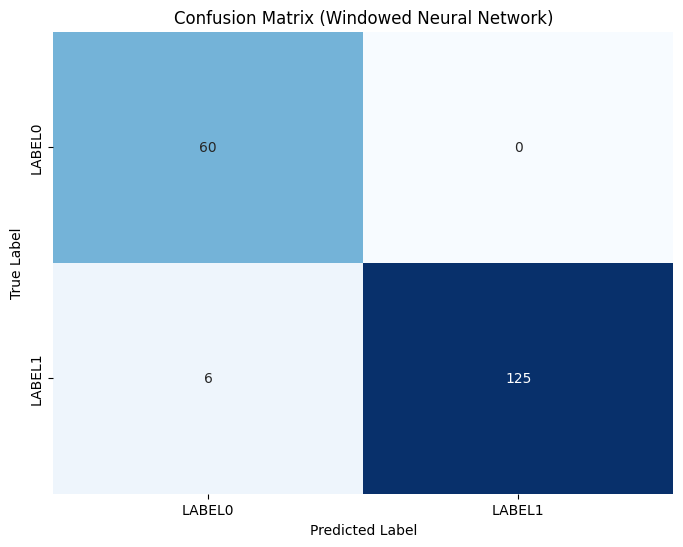

In [8]:
# Evaluate the model on the test set
loss_windowed, accuracy_windowed = model_windowed.evaluate(X_test_windowed, y_test_windowed_encoded, verbose=0)
print(f"Test Loss (Windowed NN): {loss_windowed:.4f}")
print(f"Test Accuracy (Windowed NN): {accuracy_windowed:.4f}")

# Make predictions
y_pred_proba_windowed = model_windowed.predict(X_test_windowed)
y_pred_nn_windowed = np.argmax(y_pred_proba_windowed, axis=1)

# Inverse transform labels for classification report
y_test_labels_windowed = label_encoder_windowed.inverse_transform(y_test_windowed_encoded)
y_pred_labels_windowed = label_encoder_windowed.inverse_transform(y_pred_nn_windowed)

# Print classification report
print("\nClassification Report (Windowed Neural Network):")
print(classification_report(y_test_labels_windowed, y_pred_labels_windowed))

# Plot confusion matrix
cm_nn_windowed = confusion_matrix(y_test_labels_windowed, y_pred_labels_windowed)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn_windowed, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_encoder_windowed.classes_, yticklabels=label_encoder_windowed.classes_)
plt.title('Confusion Matrix (Windowed Neural Network)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Convert Windowed Model to TensorFlow Lite

In [9]:
# Define a representative dataset generator for full integer quantization
def representative_dataset_gen():
    # Use a small subset of the training data for calibration
    # It's important to use actual input data from your use case
    # for accurate quantization.
    for i in range(min(100, X_train_windowed.shape[0])):
        # The representative dataset must be in float32 as the original model expects float32 input.
        # This provides the range for the float32 to int8 quantization at the model input.
        yield [X_train_windowed[i:i+1].astype(np.float32)]

# Convert the Keras model to TensorFlow Lite format
converter_windowed = tf.lite.TFLiteConverter.from_keras_model(model_windowed)

# Enable optimizations for full integer quantization
converter_windowed.optimizations = [tf.lite.Optimize.DEFAULT]

# Specify the representative dataset
converter_windowed.representative_dataset = representative_dataset_gen

# Ensure only integer operations are used, and set input/output types as requested
converter_windowed.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# Set input to float32. The converter will add a Quantize op from float32 to int8.
converter_windowed.inference_input_type = tf.float32
converter_windowed.inference_output_type = tf.int8 # Set output to int8

tflite_model_windowed = converter_windowed.convert()

# Save the TFLite model to a file
tflite_file_path_windowed = 'nn_model_windowed_quantized.tflite' # Updated filename
with open(tflite_file_path_windowed, 'wb') as f:
    f.write(tflite_model_windowed)

print(f"Windowed Neural Network model successfully exported to {tflite_file_path_windowed} with full integer quantization (float32 I/O, int8 O/O) using a representative dataset.")
print("When performing inference, convert your int16 data to float32 before feeding it to this TFLite model.")
print("You can now import this .tflite file into STM32Cube.AI for further conversion and optimization for your STM32 microcontroller.")

INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmp3unzdu4w/assets


INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmp3unzdu4w/assets


Saved artifact at '/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmp3unzdu4w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20350), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  4849103888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4849105232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4849104848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4849104272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4849104656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4849106768: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/mirko/Developer/SWDPProject/pipeline/venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1779802952.548402  843022 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779802952.548416  843022 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779802952.548586  843022 reader.cc:83] Reading SavedModel from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmp3unzdu4w
I0000 00:00:1779802952.548835  843022 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779802952.548838  843022 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmp3unzdu4w
I0000 00:00:1779802952.550508  843022 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1779802952.550816  843022 loader.cc:236] Restori

Windowed Neural Network model successfully exported to nn_model_windowed_quantized.tflite with full integer quantization (float32 I/O, int8 O/O) using a representative dataset.
When performing inference, convert your int16 data to float32 before feeding it to this TFLite model.
You can now import this .tflite file into STM32Cube.AI for further conversion and optimization for your STM32 microcontroller.
